
# Google Colab Lab Assignment — Pretrained Model

**Course Name:** Generative AI Lab  
**Lab Title:** CNN Image Classification and Transfer Learning on Brain MRI Images  
**Student Name:** Piyush Jangade  
**PRN Number:** 20240111040  
**Batch:** A1  
**Date of Submission:** 15-08-2026  

## Research Paper

**Krishnapriya, S. & Karuna, Y. (2023).** *Pre-trained deep learning models for brain MRI image classification.* Frontiers in Human Neuroscience, 17, 1150120.  
DOI: `10.3389/fnhum.2023.1150120`

**Research paper:** https://www.frontiersin.org/journals/human-neuroscience/articles/10.3389/fnhum.2023.1150120/full

**Dataset:** Brain MRI Images for Brain Tumor Detection — Navoneel Chakrabarty  
https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection

---

## Research Paper Study and Implementation

The selected paper investigates pretrained VGG-19, VGG-16, ResNet50 and InceptionV3 models for binary brain MRI classification using data preprocessing, data augmentation and transfer learning. The paper reports that VGG-19 achieved the strongest result among its tested models, with 99.48% accuracy, 98.76% recall, approximately 100% precision and 99.17% F1-score. ResNet50 achieved 97.92% accuracy, 87.27% recall, 77.77% precision and 82.24% F1-score.

This notebook implements the assignment requirement using **two models on the same dataset**:

1. **CNN trained from scratch**
2. **ImageNet-pretrained ResNet50 with transfer learning and fine-tuning**

The notebook evaluates both models using accuracy, precision, recall, F1-score and confusion matrices.



## Objective

1. Study a research paper utilizing a pretrained CNN model.
2. Prepare a brain MRI image dataset for binary classification.
3. Implement a CNN model from scratch.
4. Implement and fine-tune a pretrained ResNet50 model.
5. Visualize feature maps from the CNN.
6. Compare both models using accuracy, precision, recall, F1-score and confusion matrices.
7. Compare the ResNet50 implementation with the results reported in the selected research paper.



# Task 1: Research Paper Selection and Dataset Preparation

## Dataset Description

The selected dataset is **Brain MRI Images for Brain Tumor Detection** by Navoneel Chakrabarty. It contains two classes:

- **YES** — MRI image containing a brain tumor
- **NO** — MRI image without a brain tumor

The original dataset is small and class-imbalanced. The selected research paper reports a balanced/augmented dataset of **305 images: 155 tumor and 150 non-tumor images**.

### Dataset link

https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection

### Preprocessing

The pipeline:

1. Downloads the dataset.
2. Detects the `yes` and `no` folders.
3. Creates a stratified train/validation/test split.
4. Resizes images to `224 × 224`.
5. Converts images to RGB.
6. Applies augmentation only to the training pipeline.
7. Uses ImageNet preprocessing for ResNet50.
8. Uses normalized `[0,1]` pixels for the scratch CNN.

> **Important:** Augmentation is applied only after splitting so that augmented copies of a test image cannot leak into training.


In [3]:

# ============================================================
# Task 1 — Install / import required libraries
# ============================================================

!pip -q install kagglehub

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\piyus\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


TensorFlow: 2.20.0
GPU available: []


In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, VGG19, InceptionV3
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess


In [4]:
%pip install kagglehub


  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.37-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.2-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.37-py3-none-any.whl (262 kB)

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -----------------------------------

In [5]:

# ============================================================
# Download dataset from Kaggle
# ============================================================

import kagglehub

dataset_path = kagglehub.dataset_download(
    "navoneel/brain-mri-images-for-brain-tumor-detection"
)

print("Downloaded dataset:", dataset_path)

# Locate YES/NO folders regardless of the exact Kaggle cache path.
candidate_dirs = []

for root, dirs, files in os.walk(dataset_path):
    lower_dirs = {d.lower() for d in dirs}
    if "yes" in lower_dirs and "no" in lower_dirs:
        candidate_dirs.append(root)

if not candidate_dirs:
    raise FileNotFoundError(
        "Could not automatically locate folders named 'yes' and 'no'. "
        "Please inspect dataset_path and set DATASET_ROOT manually."
    )

DATASET_ROOT = Path(candidate_dirs[0])

YES_DIR = DATASET_ROOT / "yes"
NO_DIR = DATASET_ROOT / "no"

print("Dataset root:", DATASET_ROOT)
print("YES:", len(list(YES_DIR.glob("*"))))
print("NO :", len(list(NO_DIR.glob("*"))))


Downloaded dataset: C:\Users\piyus\.cache\kagglehub\datasets\navoneel\brain-mri-images-for-brain-tumor-detection\versions\1
Dataset root: C:\Users\piyus\.cache\kagglehub\datasets\navoneel\brain-mri-images-for-brain-tumor-detection\versions\1
YES: 155
NO : 98


Total images: 253


,count
class_name,
YES,155
NO,98


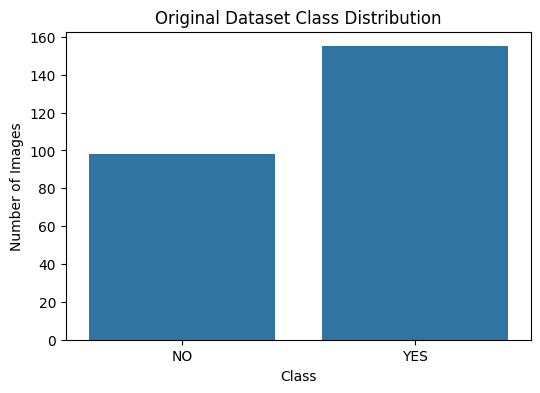

In [6]:

# ============================================================
# Create a dataframe of image paths and labels
# ============================================================

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

records = []

for label_name, folder in [("NO", NO_DIR), ("YES", YES_DIR)]:
    for file in folder.iterdir():
        if file.suffix.lower() in VALID_EXTENSIONS:
            records.append({
                "filepath": str(file),
                "label": 1 if label_name == "YES" else 0,
                "class_name": label_name
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
display(df["class_name"].value_counts().to_frame("count"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class_name")
plt.title("Original Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


In [26]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

def create_model_generators(preprocess_fn):
    """Creates train, val, and test data generators for a specific model's preprocessing."""
    train_aug = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=12,
        width_shift_range=0.08,
        height_shift_range=0.08,
        zoom_range=0.10,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    eval_gen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_data = train_aug.flow_from_dataframe(
        train_df, x_col="filepath", y_col="class_name",
        target_size=IMG_SIZE, color_mode="rgb", class_mode="binary",
        batch_size=BATCH_SIZE, shuffle=True, seed=SEED
    )

    val_data = eval_gen.flow_from_dataframe(
        val_df, x_col="filepath", y_col="class_name",
        target_size=IMG_SIZE, color_mode="rgb", class_mode="binary",
        batch_size=BATCH_SIZE, shuffle=False
    )

    test_data = eval_gen.flow_from_dataframe(
        test_df, x_col="filepath", y_col="class_name",
        target_size=IMG_SIZE, color_mode="rgb", class_mode="binary",
        batch_size=BATCH_SIZE, shuffle=False
    )

    return train_data, val_data, test_data

# Create generators for VGG-16, VGG-19, and InceptionV3
vgg16_train, vgg16_val, vgg16_test = create_model_generators(vgg16_preprocess)
vgg19_train, vgg19_val, vgg19_test = create_model_generators(vgg19_preprocess)
inception_train, inception_val, inception_test = create_model_generators(inception_preprocess)


Found 177 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 177 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 177 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.


In [27]:
def build_transfer_model(base_model_cls, model_name, input_shape=(224, 224, 3)):
    """Instantiates a pretrained base model with a custom classification head."""
    base_model = base_model_cls(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False  # Freeze backbone for Stage 1

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="tumor_probability")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model, base_model


In [ ]:
def train_and_finetune(base_model_cls, model_name, train_gen, val_gen, unfreeze_layers=6):
    print(f"\n============================================================")
    print(f" Training: {model_name}")
    print(f"============================================================")
    
    model, base_model = build_transfer_model(base_model_cls, model_name)
    
    # ------------------------------------------------------------
    # Stage 1: Train Classification Head Only (Backbone Frozen)
    # ------------------------------------------------------------
    callbacks_head = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7)
    ]
    
    print(f"--- Stage 1: Transfer Learning ({model_name}) ---")
    history_head = model.fit(
        train_gen, validation_data=val_gen,
        epochs=8, callbacks=callbacks_head, verbose=1
    )
    
    # ------------------------------------------------------------
    # Stage 2: Fine-Tuning Upper Layers
    # ------------------------------------------------------------
    base_model.trainable = True
    
    # Freeze all except top unfreeze_layers
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
        
    # Freeze BatchNormalization layers to preserve stats on small datasets
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Lower LR for fine-tuning
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    callbacks_ft = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7)
    ]
    
    print(f"--- Stage 2: Fine-Tuning ({model_name}) ---")
    history_ft = model.fit(
        train_gen, validation_data=val_gen,
        epochs=12, callbacks=callbacks_ft, verbose=1
    )
    
    return model, history_head, history_ft

# Run training for all three models
vgg16_model, vgg16_hist_head, vgg16_hist_ft = train_and_finetune(
    VGG16, "VGG16_Transfer_Learning", vgg16_train, vgg16_val, unfreeze_layers=4
)

vgg19_model, vgg19_hist_head, vgg19_hist_ft = train_and_finetune(
    VGG19, "VGG19_Transfer_Learning", vgg19_train, vgg19_val, unfreeze_layers=5
)

inception_model, inception_hist_head, inception_hist_ft = train_and_finetune(
    InceptionV3, "InceptionV3_Transfer_Learning", inception_train, inception_val, unfreeze_layers=30
)



 Training: VGG16_Transfer_Learning
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
--- Stage 1: Transfer Learning (VGG16_Transfer_Learning) ---


c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 110s 9s/step - accuracy: 0.6328 - loss: 1.5276 - val_accuracy: 0.8421 - val_loss: 0.3263 - learning_rate: 0.0010
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 98s 8s/step - accuracy: 0.7910 - loss: 0.6645 - val_accuracy: 0.8421 - val_loss: 0.3661 - learning_rate: 0.0010
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 94s 8s/step - accuracy: 0.8701 - loss: 0.4230 - val_accuracy: 0.8684 - val_loss: 0.3756 - learning_rate: 0.0010
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 99s 8s/step - accuracy: 0.8757 - loss: 0.3827 - val_accuracy: 0.8684 - val_loss: 0.3024 - learning_rate: 3.0000e-04
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.8644 - loss: 0.4125 - val_accuracy: 0.8684 - val_loss: 0.2875 - learning_rate: 3.0000e-04
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 109s 9s/step - accuracy: 0.8192 - loss: 0.4177 - val_accuracy: 0.8947 - val_loss: 0.3022 - learning_rate: 3.0000e-04
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 142s 10s/step - accuracy: 0.8531 - loss: 0.3557 - val_a

In [7]:

# ============================================================
# Stratified train / validation / test split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

display(pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": val_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
}).fillna(0).astype(int))


Train: 177
Validation: 38
Test: 38


,Train,Validation,Test
class_name,,,
YES,108,24,23
NO,69,14,15


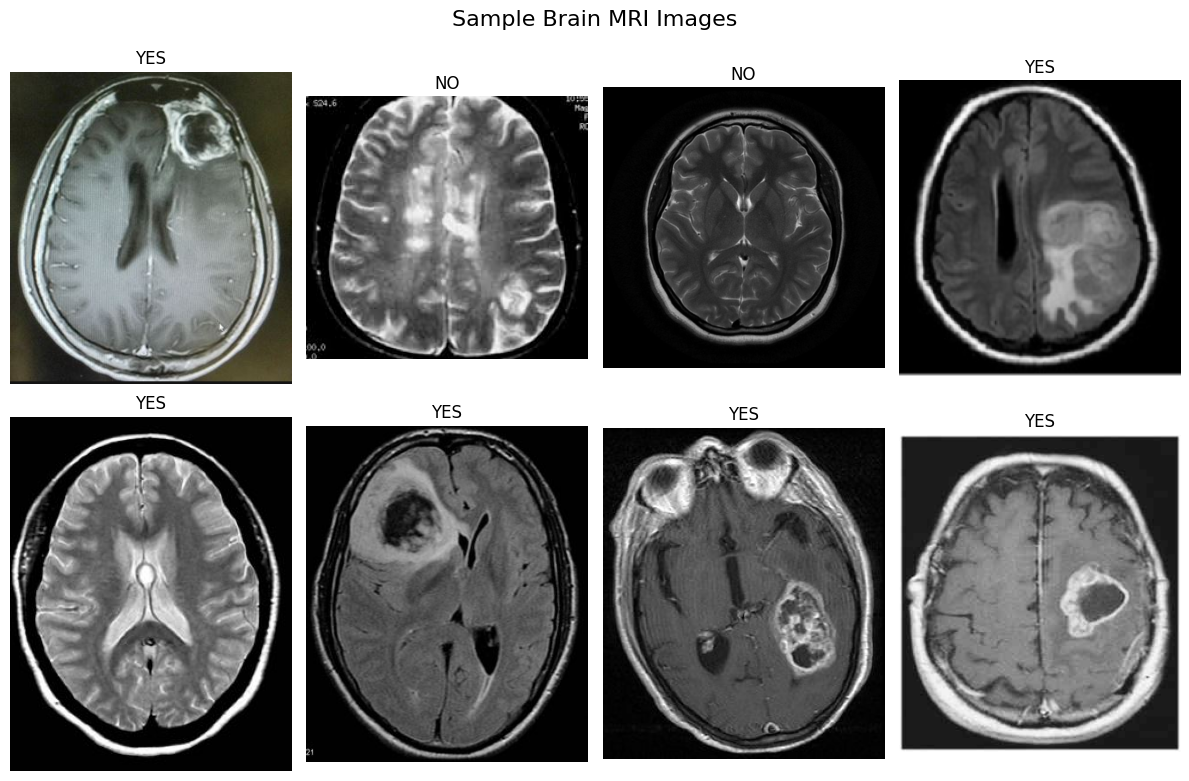

In [8]:

# ============================================================
# Visualize sample MRI images
# ============================================================

sample_df = df.sample(
    min(8, len(df)),
    random_state=SEED
).reset_index(drop=True)

plt.figure(figsize=(12, 8))

for i, row in sample_df.iterrows():
    img = Image.open(row["filepath"]).convert("RGB")

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(row["class_name"])
    plt.axis("off")

plt.suptitle("Sample Brain MRI Images", fontsize=16)
plt.tight_layout()
plt.show()



# Task 2: Model Implementation and Fine-Tuning

## Model A — CNN from Scratch

The scratch CNN does not use pretrained convolutional weights. Its architecture is:

`Input → Conv2D → BatchNorm → ReLU → MaxPool → Conv2D → BatchNorm → ReLU → MaxPool → Conv2D → ReLU → GlobalAveragePooling → Dense → Dropout → Output`

## Model B — ResNet50 Transfer Learning

ResNet50 is initialized with ImageNet pretrained weights. The original classification head is removed and replaced with a binary classifier.

Training is performed in two stages:

1. **Transfer learning stage:** ResNet50 backbone frozen; only the new classifier is trained.
2. **Fine-tuning stage:** The upper ResNet50 layers are unfrozen and trained with a small learning rate.

This follows the core transfer-learning idea used by the selected research paper: pretrained representations are transferred to the brain MRI classification task.


In [11]:

# ============================================================
# Image generators
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Scratch CNN: pixels scaled to [0,1]
scratch_train_aug = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

scratch_eval = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

scratch_train_gen = scratch_train_aug.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

scratch_val_gen = scratch_eval.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

scratch_test_gen = scratch_eval.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ResNet50 uses ImageNet preprocessing.
resnet_train_aug = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

resnet_eval = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

resnet_train_gen = resnet_train_aug.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

resnet_val_gen = resnet_eval.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

resnet_test_gen = resnet_eval.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="class_name",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class indices:", scratch_train_gen.class_indices)


Found 177 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 177 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Found 38 validated image filenames belonging to 2 classes.
Class indices: {'NO': 0, 'YES': 1}


In [12]:

# ============================================================
# CNN FROM SCRATCH
# ============================================================

def build_scratch_cnn(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    feature_map = x

    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, (3, 3), padding="same")(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="CNN_From_Scratch")

    feature_model = keras.Model(
        inputs,
        feature_map,
        name="CNN_Feature_Extractor"
    )

    return model, feature_model


scratch_model, scratch_feature_model = build_scratch_cnn()

scratch_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

scratch_model.summary()


Model: "CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,337 (1.61 MB)

 Trainable params: 421,889 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:

# ============================================================
# Train CNN from scratch
# ============================================================

EPOCHS_SCRATCH = 20

scratch_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

history_scratch = scratch_model.fit(
    scratch_train_gen,
    validation_data=scratch_val_gen,
    epochs=EPOCHS_SCRATCH,
    callbacks=scratch_callbacks,
    verbose=1
)


c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 751ms/step - accuracy: 0.6610 - loss: 0.7519 - val_accuracy: 0.6316 - val_loss: 0.6374 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 744ms/step - accuracy: 0.6780 - loss: 0.6568 - val_accuracy: 0.6316 - val_loss: 0.6503 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 719ms/step - accuracy: 0.7062 - loss: 0.5830 - val_accuracy: 0.6316 - val_loss: 0.6603 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 730ms/step - accuracy: 0.6384 - loss: 0.5943 - val_accuracy: 0.6316 - val_loss: 0.6738 - learning_rate: 3.0000e-04
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 779ms/step - accuracy: 0.7006 - loss: 0.5722 - val_accuracy: 0.6316 - val_loss: 0.7569 - learning_rate: 3.0000e-04
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7288 - loss: 0.5544 - val_accuracy: 0.6316 - val_loss: 0.7931 - learning_rate: 9.0000e-05


In [ ]:

# ============================================================
# ResNet50 Transfer Learning
# ============================================================

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_resnet.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.40)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid",    name="tumor_probability"
)(x)

resnet_model = keras.Model(
    inputs,
    outputs,
    name="ResNet50_Transfer_Learning"
)

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()


Model: "ResNet50_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tumor_probability (Dense)       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:

# ============================================================
# Stage 1 — Train only the new classification head
# ============================================================

EPOCHS_HEAD = 8

resnet_head_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

history_resnet_head = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=resnet_head_callbacks,
    verbose=1
)


Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 939ms/step - accuracy: 0.6836 - loss: 0.7166 - val_accuracy: 0.7895 - val_loss: 0.4955 - learning_rate: 0.0010
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8362 - loss: 0.3730 - val_accuracy: 0.8684 - val_loss: 0.4799 - learning_rate: 0.0010
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.8531 - loss: 0.3949 - val_accuracy: 0.8421 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8814 - loss: 0.2716 - val_accuracy: 0.8947 - val_loss: 0.3089 - learning_rate: 0.0010
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9096 - loss: 0.2340 - val_accuracy: 0.8684 - val_loss: 0.2918 - learning_rate: 0.0010
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9040 - loss: 0.2927 - val_accuracy: 0.8947 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 751ms/step - accuracy: 0.9209 - loss: 0.2462 - val_accuracy: 0.

In [18]:

# ============================================================
# Stage 2 — Fine-tune upper ResNet50 layers
# ============================================================

# Freeze most of the backbone and unfreeze the last ~30 layers.
base_resnet.trainable = True

for layer in base_resnet.layers[:-30]:
    layer.trainable = False

# BatchNorm layers are kept frozen for stable fine-tuning on the small dataset.
for layer in base_resnet.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_FINE_TUNE = 12

resnet_finetune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    )
]

history_resnet_finetune = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=resnet_finetune_callbacks,
    verbose=1
)


Epoch 1/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step - accuracy: 0.9153 - loss: 0.2320 - val_accuracy: 0.9211 - val_loss: 0.2868 - learning_rate: 1.0000e-05
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.9096 - loss: 0.2508 - val_accuracy: 0.8947 - val_loss: 0.2842 - learning_rate: 1.0000e-05
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9379 - loss: 0.1802 - val_accuracy: 0.9211 - val_loss: 0.2963 - learning_rate: 1.0000e-05
Epoch 4/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 953ms/step - accuracy: 0.9379 - loss: 0.1771 - val_accuracy: 0.8947 - val_loss: 0.3015 - learning_rate: 1.0000e-05
Epoch 5/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 914ms/step - accuracy: 0.9492 - loss: 0.1385 - val_accuracy: 0.8947 - val_loss: 0.2986 - learning_rate: 3.0000e-06
Epoch 6/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9492 - loss: 0.1363 - val_accuracy: 0.8947 - val_loss: 0.2995 - learning_rate: 3.0000e-06



## Feature Map Visualization

Feature maps show intermediate visual representations learned by the CNN. Early layers generally respond to simple patterns such as edges and textures, while deeper layers represent more complex visual structures.


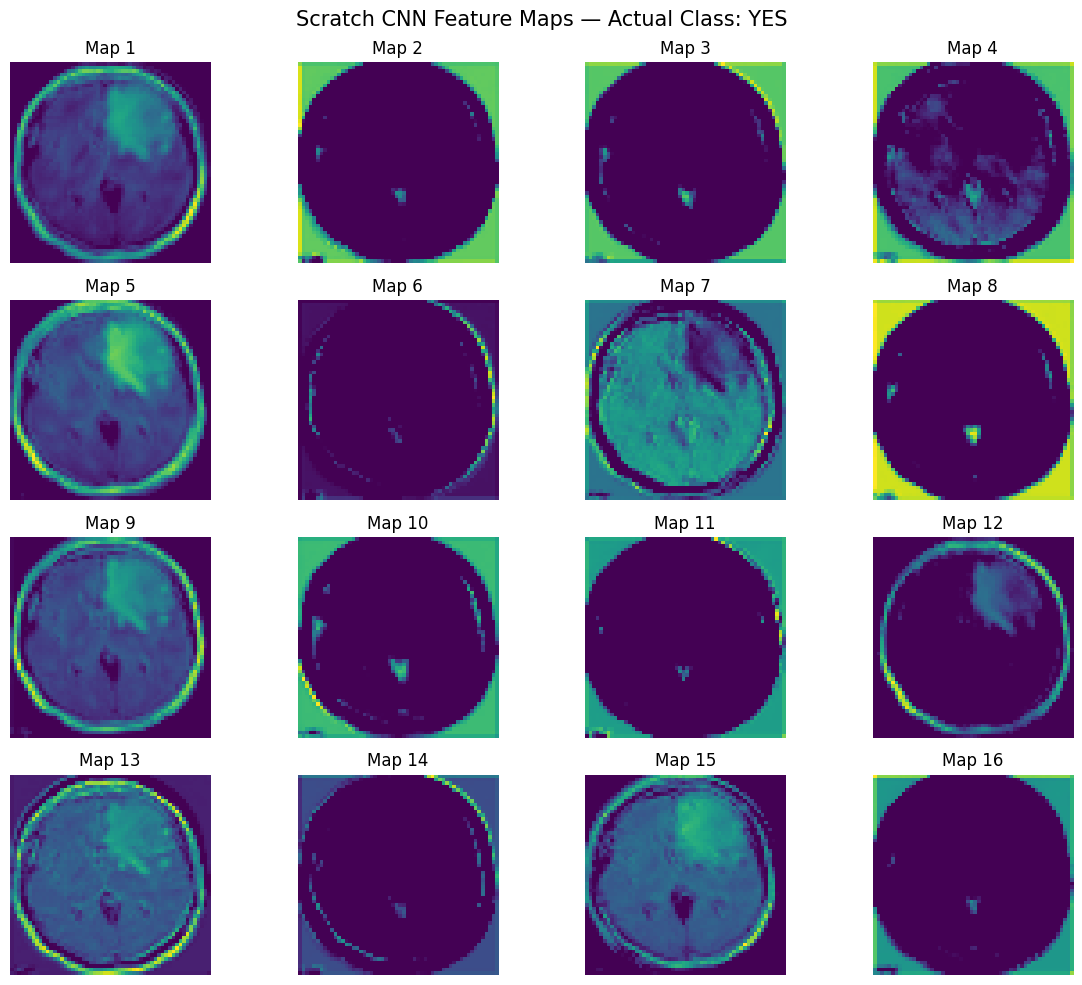

In [19]:

# ============================================================
# Visualize feature maps from the scratch CNN
# ============================================================

sample_path = test_df.iloc[0]["filepath"]
sample_label = test_df.iloc[0]["class_name"]

img = Image.open(sample_path).convert("RGB").resize(IMG_SIZE)
img_array = np.asarray(img, dtype=np.float32) / 255.0
input_tensor = np.expand_dims(img_array, axis=0)

feature_maps = scratch_feature_model.predict(input_tensor, verbose=0)[0]

n_maps = min(16, feature_maps.shape[-1])

plt.figure(figsize=(12, 10))

for i in range(n_maps):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[:, :, i], cmap="viridis")
    plt.axis("off")
    plt.title(f"Map {i+1}")

plt.suptitle(
    f"Scratch CNN Feature Maps — Actual Class: {sample_label}",
    fontsize=15
)

plt.tight_layout()
plt.show()



# Task 3: Model Evaluation and Performance Comparison

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training/validation accuracy and loss

For the binary classification task, **YES = 1** represents a tumor image and **NO = 0** represents a non-tumor image.


In [20]:

# ============================================================
# Evaluation helper
# ============================================================

def evaluate_binary_model(model, generator, model_name):
    generator.reset()

    probabilities = model.predict(generator, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    true_labels = generator.classes

    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, zero_division=0)
    recall = recall_score(true_labels, predictions, zero_division=0)
    f1 = f1_score(true_labels, predictions, zero_division=0)

    cm = confusion_matrix(true_labels, predictions)

    print(f"\n{'='*55}")
    print(model_name)
    print(f"{'='*55}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            true_labels,
            predictions,
            target_names=["NO", "YES"],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Confusion Matrix": cm
    }


scratch_results = evaluate_binary_model(
    scratch_model,
    scratch_test_gen,
    "CNN From Scratch"
)

resnet_results = evaluate_binary_model(
    resnet_model,
    resnet_test_gen,
    "ResNet50 Transfer Learning + Fine-Tuning"
)



CNN From Scratch
Accuracy : 0.6053
Precision: 0.6053
Recall   : 1.0000
F1-score : 0.7541

Classification Report:
              precision    recall  f1-score   support

          NO       0.00      0.00      0.00        15
         YES       0.61      1.00      0.75        23

    accuracy                           0.61        38
   macro avg       0.30      0.50      0.38        38
weighted avg       0.37      0.61      0.46        38



c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



ResNet50 Transfer Learning + Fine-Tuning
Accuracy : 0.8684
Precision: 0.8750
Recall   : 0.9130
F1-score : 0.8936

Classification Report:
              precision    recall  f1-score   support

          NO       0.86      0.80      0.83        15
         YES       0.88      0.91      0.89        23

    accuracy                           0.87        38
   macro avg       0.87      0.86      0.86        38
weighted avg       0.87      0.87      0.87        38



,Model,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,CNN From Scratch,60.53,60.53,100.00,75.41
1,ResNet50 Transfer Learning + Fine-Tuning,86.84,87.50,91.30,89.36


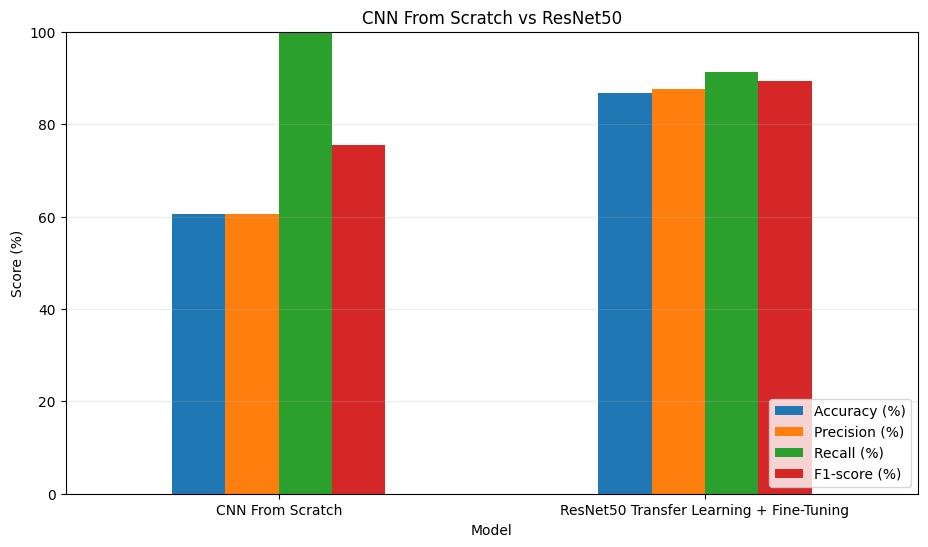

In [21]:

# ============================================================
# Comparison table
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Model": scratch_results["Model"],
        "Accuracy (%)": scratch_results["Accuracy"] * 100,
        "Precision (%)": scratch_results["Precision"] * 100,
        "Recall (%)": scratch_results["Recall"] * 100,
        "F1-score (%)": scratch_results["F1-score"] * 100
    },
    {
        "Model": resnet_results["Model"],
        "Accuracy (%)": resnet_results["Accuracy"] * 100,
        "Precision (%)": resnet_results["Precision"] * 100,
        "Recall (%)": resnet_results["Recall"] * 100,
        "F1-score (%)": resnet_results["F1-score"] * 100
    }
])

display(
    comparison_df.style
    .format({
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1-score (%)": "{:.2f}"
    })
    .highlight_max(
        subset=["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)"]
    )
)

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("CNN From Scratch vs ResNet50")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.legend(loc="lower right")
plt.show()


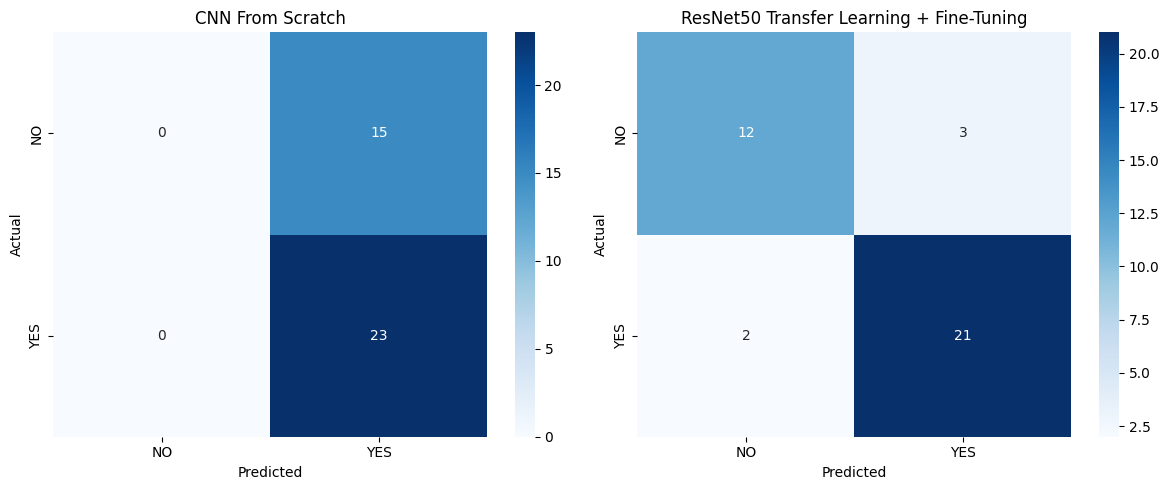

In [22]:

# ============================================================
# Confusion matrices
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, result in zip(
    axes,
    [scratch_results, resnet_results]
):
    sns.heatmap(
        result["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["NO", "YES"],
        yticklabels=["NO", "YES"],
        ax=ax
    )

    ax.set_title(result["Model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


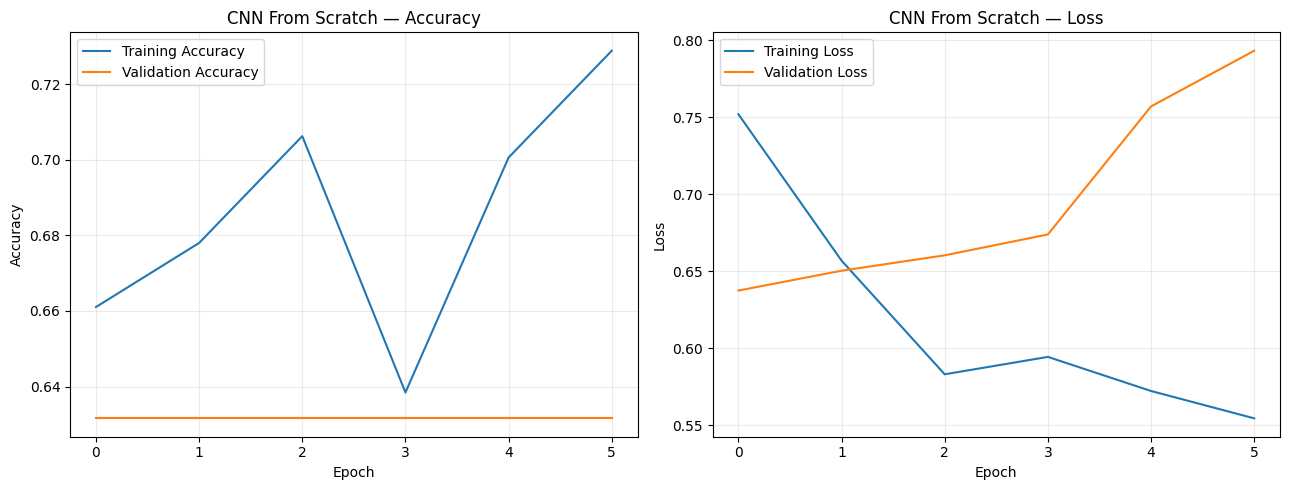

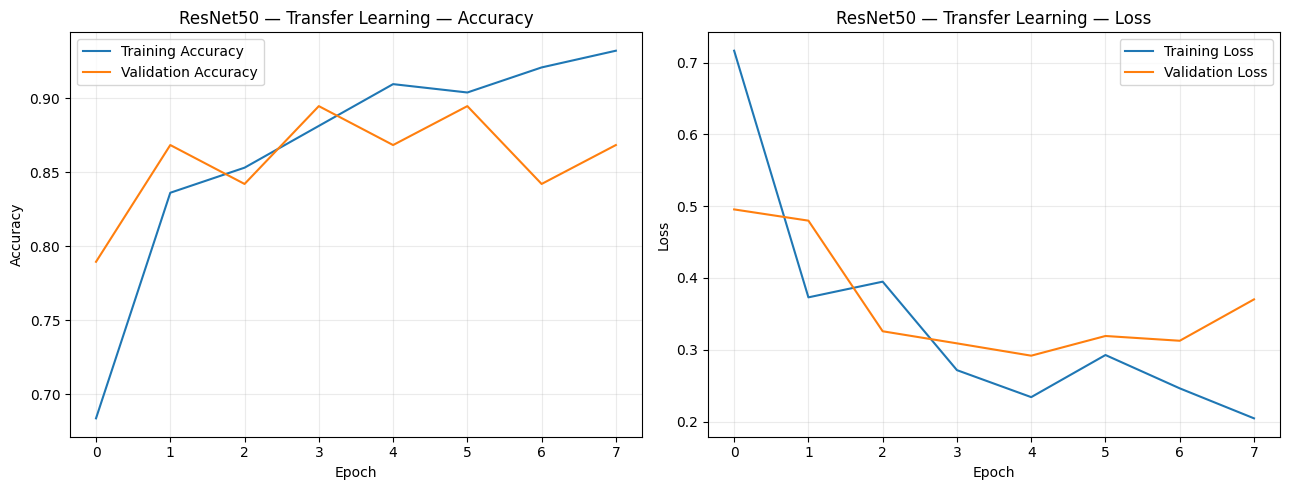

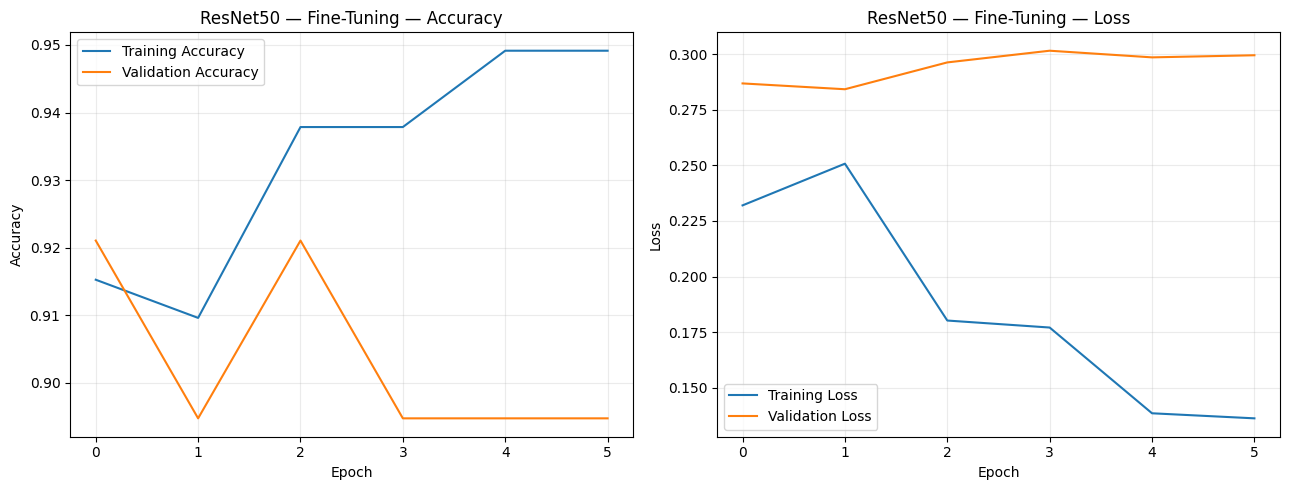

In [23]:

# ============================================================
# Accuracy and loss curves
# ============================================================

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(history.history["accuracy"], label="Training Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{title} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(history.history["loss"], label="Training Loss")
    axes[1].plot(history.history["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{title} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


plot_history(history_scratch, "CNN From Scratch")
plot_history(history_resnet_head, "ResNet50 — Transfer Learning")

plot_history(history_resnet_finetune, "ResNet50 — Fine-Tuning")



# Comparison with the Research Paper

The selected paper reports the following results for the same broad brain-MRI classification problem:

| Model | Accuracy | Recall | Precision | F1-score |
|---|---:|---:|---:|---:|
| VGG-19 | 99.48% | 98.76% | ~100% | 99.17% |
| VGG-16 | 99.00% | 98.18% | ~100% | 99.08% |
| **ResNet50** | **97.92%** | **87.27%** | **77.77%** | **82.24%** |
| InceptionV3 | 81.25% | 63.25% | 53.84% | 58.16% |

The paper used 305 images after augmentation, with 155 tumor images and 150 non-tumor images. It used a 70/30 train/test split and created a validation set from the test portion. Data augmentation was used to address the small and imbalanced dataset.

**Our experiment is not expected to reproduce exactly the same numbers**, because the split, augmentation procedure, random initialization, training schedule, hardware and fine-tuning strategy may differ. The table below should therefore be populated using the actual metrics generated by this notebook rather than copying the paper's results.

> Do not manually enter your model's accuracy before running the notebook. The evaluation cell calculates the actual results.


In [24]:

# ============================================================
# Automatic paper comparison
# ============================================================

paper_resnet = {
    "Accuracy (%)": 97.92,
    "Precision (%)": 77.77,
    "Recall (%)": 87.27,
    "F1-score (%)": 82.24
}

our_resnet = comparison_df[
    comparison_df["Model"] == "ResNet50 Transfer Learning + Fine-Tuning"
].iloc[0]

paper_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Research Paper ResNet50 (%)": [
        paper_resnet["Accuracy (%)"],
        paper_resnet["Precision (%)"],
        paper_resnet["Recall (%)"],
        paper_resnet["F1-score (%)"]
    ],
    "Our ResNet50 (%)": [
        our_resnet["Accuracy (%)"],
        our_resnet["Precision (%)"],
        our_resnet["Recall (%)"],
        our_resnet["F1-score (%)"]
    ]
})

paper_comparison["Difference (%)"] = (
    paper_comparison["Our ResNet50 (%)"]
    - paper_comparison["Research Paper ResNet50 (%)"]
)

display(
    paper_comparison.style.format({
        "Research Paper ResNet50 (%)": "{:.2f}",
        "Our ResNet50 (%)": "{:.2f}",
        "Difference (%)": "{:+.2f}"
    })
)


,Metric,Research Paper ResNet50 (%),Our ResNet50 (%),Difference (%)
0,Accuracy,97.92,86.84,-11.08
1,Precision,77.77,87.50,+9.73
2,Recall,87.27,91.30,+4.03
3,F1-score,82.24,89.36,+7.12



# Result Visualization and Discussion

After executing the notebook, the generated graphs and tables provide:

1. Dataset class distribution.
2. Sample MRI images.
3. CNN feature maps.
4. CNN training/validation accuracy.
5. CNN training/validation loss.
6. ResNet50 transfer-learning accuracy and loss.
7. ResNet50 fine-tuning accuracy and loss.
8. Confusion matrices for both models.
9. A quantitative comparison of accuracy, precision, recall and F1-score.
10. A comparison between our ResNet50 implementation and the research paper.

## Expected Interpretation

The CNN from scratch must learn low-level and high-level visual features entirely from the small MRI dataset. This can make it more susceptible to overfitting.

ResNet50 starts with features learned from ImageNet. Transfer learning therefore provides a strong initialization and generally requires less task-specific training. Fine-tuning the upper layers allows the representation to adapt to MRI-specific visual patterns.

The final conclusion should be based on the **actual test-set metrics produced by the notebook**.

Because this is a medical-image classification task, the model should be considered an experimental academic classifier rather than a clinical diagnostic system.



# Conclusion

This practical implemented an end-to-end brain MRI image classification pipeline using two approaches:

- A convolutional neural network trained from scratch.
- An ImageNet-pretrained ResNet50 model using transfer learning followed by fine-tuning.

Both models were trained and evaluated on the same binary MRI classification dataset. Accuracy, precision, recall, F1-score and confusion matrices were used for quantitative comparison. Feature-map visualization was also performed to inspect intermediate representations learned by the scratch CNN.

The comparison demonstrates the practical value of transfer learning for small image datasets. The pretrained ResNet50 can reuse general visual representations and adapt them to the target MRI classification problem through fine-tuning.

The final numerical conclusion should be taken from the executed evaluation results rather than assumed in advance.



# Declaration

I, **Piyush Jangade**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

The implementation uses the selected research paper as the methodological reference and clearly distinguishes the reported research-paper results from the results obtained by this notebook.

**GitHub Repository Link:**  
https://github.com/Piyush-ouch/GEN-AI-Assignment-1.git

**Signature:** Piyush Jangade



# Submission Checklist

- [x] Research paper details and summary
- [x] Research paper dataset link and description
- [x] CNN implementation from scratch
- [x] ResNet50 transfer learning
- [x] ResNet50 fine-tuning
- [x] Feature-map visualization
- [x] Accuracy, precision, recall and F1-score
- [x] Confusion matrices
- [x] Accuracy and loss curves
- [x] Comparison with research-paper ResNet50 results
- [x] Conclusion and discussion
- [x] Declaration
- [ ] Execute all cells before submission
- [ ] Add screenshots of final metrics/graphs if required
- [ ] Upload the final executed notebook to GitHub
